<a href="https://colab.research.google.com/github/kenyamags/trabalho-2-IIA/blob/main/Trabalho_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Configuração para exibição limpa das tabelas do Pandas no console
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

In [ ]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(activated_x):
    return activated_x * (1 - activated_x)

def sigmoid_bipolar(x):
    return (2 / (1 + np.exp(-x))) - 1

def tanh(x):
    return np.tanh(x)

def plot_activation_functions():
    x_vals = np.linspace(-6, 6, 200)
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.plot(x_vals, sigmoid(x_vals), 'b', linewidth=2)
    plt.title('Sigmóide Binária')
    plt.grid(True)

    plt.subplot(1, 3, 2)
    plt.plot(x_vals, sigmoid_bipolar(x_vals), 'r', linewidth=2)
    plt.title('Sigmóide Bipolar')
    plt.grid(True)

    plt.subplot(1, 3, 3)
    plt.plot(x_vals, tanh(x_vals), 'g', linewidth=2)
    plt.title('Tangente Hiperbólica')
    plt.grid(True)

    plt.tight_layout()
    print("Gerando Gráfico das Funções de Ativação (Parte 3)...")
    plt.show()

Gerando Gráfico das Funções de Ativação (Parte 3)...


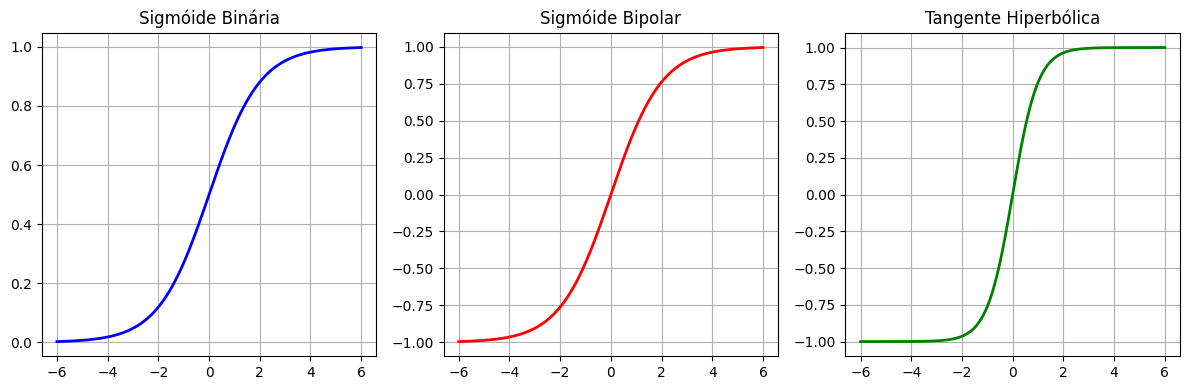

In [ ]:
class MLP:
    def __init__(self, input_size, hidden_size, output_size, lr=0.2, seed=None):
        self.lr = lr
        if seed is not None:
            np.random.seed(seed)

        # Inicialização uniforme dos pesos e biases entre -0.5 e 0.5
        self.weights_hidden = np.random.uniform(-0.5, 0.5, (input_size, hidden_size))
        self.bias_hidden = np.random.uniform(-0.5, 0.5, (1, hidden_size))

        self.weights_output = np.random.uniform(-0.5, 0.5, (hidden_size, output_size))
        self.bias_output = np.random.uniform(-0.5, 0.5, (1, output_size))

    def forward(self, X):
        self.hidden_input = np.dot(X, self.weights_hidden) + self.bias_hidden
        self.hidden_output = sigmoid(self.hidden_input)

        self.output_input = np.dot(self.hidden_output, self.weights_output) + self.bias_output
        self.final_output = sigmoid(self.output_input)
        return self.final_output

    def backward(self, X, y, output):
        error_output = y - output
        delta_output = error_output * sigmoid_derivative(output)

        error_hidden = np.dot(delta_output, self.weights_output.T)
        delta_hidden = error_hidden * sigmoid_derivative(self.hidden_output)

        # Atualização Estocástica (Padrão por Padrão)
        self.weights_output += np.dot(self.hidden_output.T, delta_output) * self.lr
        self.bias_output += np.sum(delta_output, axis=0, keepdims=True) * self.lr

        self.weights_hidden += np.dot(X.T, delta_hidden) * self.lr
        self.bias_hidden += np.sum(delta_hidden, axis=0, keepdims=True) * self.lr

        return np.sum(np.abs(error_output))

    def train(self, X, y, tolerance=0.001, max_epochs=10000):
        epoch_errors = []

        for epoch in range(max_epochs):
            total_abs_error = 0
            for i in range(len(X)):
                X_sample = X[i:i+1]
                y_sample = y[i:i+1]

                output = self.forward(X_sample)
                error = self.backward(X_sample, y_sample, output)
                total_abs_error += error

            mean_error = total_abs_error / len(X)
            epoch_errors.append(mean_error)

            if mean_error <= tolerance:
                break

        return epoch_errors, epoch + 1

# Dados estruturados do XOR (Parte 6)
X_train = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_train = np.array([[0], [1], [1], [0]])

# Executa a plotagem da primeira parte exigida antes de treinar
plot_activation_functions()

In [ ]:
print("\n" + "="*60)
print("Executando Treinamento Padrão (4 Ocultos, LR=0.2, Seed=0)")
print("="*60)
mlp_padrao = MLP(input_size=2, hidden_size=4, output_size=1, lr=0.2, seed=0)
historico_erros, epocas_padrao = mlp_padrao.train(X_train, y_train, tolerance=0.001)


Executando Treinamento Padrão (4 Ocultos, LR=0.2, Seed=0)


In [ ]:
results_A = []
results_B = []
results_C = []

# --- Experimento A: Quantidade de neurônios ---
for n in [2, 3, 4, 5]:
    epochs_local = []
    errors_local = []
    for s in range(3):
        mlp = MLP(input_size=2, hidden_size=n, output_size=1, lr=0.2, seed=s)
        errs, eps = mlp.train(X_train, y_train, tolerance=0.001, max_epochs=6000)
        epochs_local.append(eps)
        errors_local.append(errs[-1])
    results_A.append({
        "Neurônios Ocultos": n,
        "Número de Épocas (Média)": int(np.mean(epochs_local)),
        "Erro Final Médio": round(np.mean(errors_local), 6)
    })

# --- Experimento B: Taxa de Aprendizagem ---
for lr in [0.1, 0.2, 0.3, 0.4, 0.5]:
    epochs_local = []
    errors_local = []
    for s in range(3):
        mlp = MLP(input_size=2, hidden_size=4, output_size=1, lr=lr, seed=s)
        errs, eps = mlp.train(X_train, y_train, tolerance=0.001, max_epochs=6000)
        epochs_local.append(eps)
        errors_local.append(errs[-1])
    results_B.append({
        "Taxa de Aprendizagem": lr,
        "Épocas até Convergência": int(np.mean(epochs_local)),
        "Erro Final": round(np.mean(errors_local), 6)
    })

# --- Experimento C: Sementes Aleatórias ---
for s in [0, 1, 2, 3, 4]:
    mlp = MLP(input_size=2, hidden_size=4, output_size=1, lr=0.2, seed=s)
    errs, eps = mlp.train(X_train, y_train, tolerance=0.001, max_epochs=6000)
    estabilidade = "Convergiu" if eps < 6000 else "Mínimo Local"
    results_C.append({
        "Semente": f"Seed {s}",
        "Número de Épocas": eps,
        "Erro Final": round(errs[-1], 6),
        "Estabilidade": estabilidade
    })

In [ ]:
df_A = pd.DataFrame(results_A)
df_B = pd.DataFrame(results_B)
df_C = pd.DataFrame(results_C)

print("\nTABELA A: Impacto dos Neurônios Ocultos")
print(df_A.to_string(index=False))

print("\nTABELA B: Impacto da Taxa de Aprendizagem")
print(df_B.to_string(index=False))

print("\nTABELA C: Influência das Sementes Aleatórias (Estabilidade)")
print(df_C.to_string(index=False))

print("\n" + "="*60)
print("Saída da Rede para Cada Padrão (Após Treinamento)")
print("="*60)
for i in range(len(X_train)):
    pred = mlp_padrao.forward(X_train[i:i+1])
    print(f"Entrada: {X_train[i]} -> Esperado: {y_train[i][0]} -> Saída Obtida: {pred[0][0]:.4f}")



TABELA A: Impacto dos Neurônios Ocultos
 Neurônios Ocultos  Número de Épocas (Média)  Erro Final Médio
                 2                      6000          0.171612
                 3                      6000          0.152554
                 4                      6000          0.092738
                 5                      6000          0.129735

TABELA B: Impacto da Taxa de Aprendizagem
 Taxa de Aprendizagem  Épocas até Convergência  Erro Final
                  0.1                     6000    0.344686
                  0.2                     6000    0.092738
                  0.3                     6000    0.038708
                  0.4                     6000    0.029361
                  0.5                     6000    0.024477

TABELA C: Influência das Sementes Aleatórias (Estabilidade)
Semente  Número de Épocas  Erro Final Estabilidade
 Seed 0              6000    0.166348 Mínimo Local
 Seed 1              6000    0.048805 Mínimo Local
 Seed 2              6000    0.06


Exibindo Gráficos Estatísticos do Treinamento...


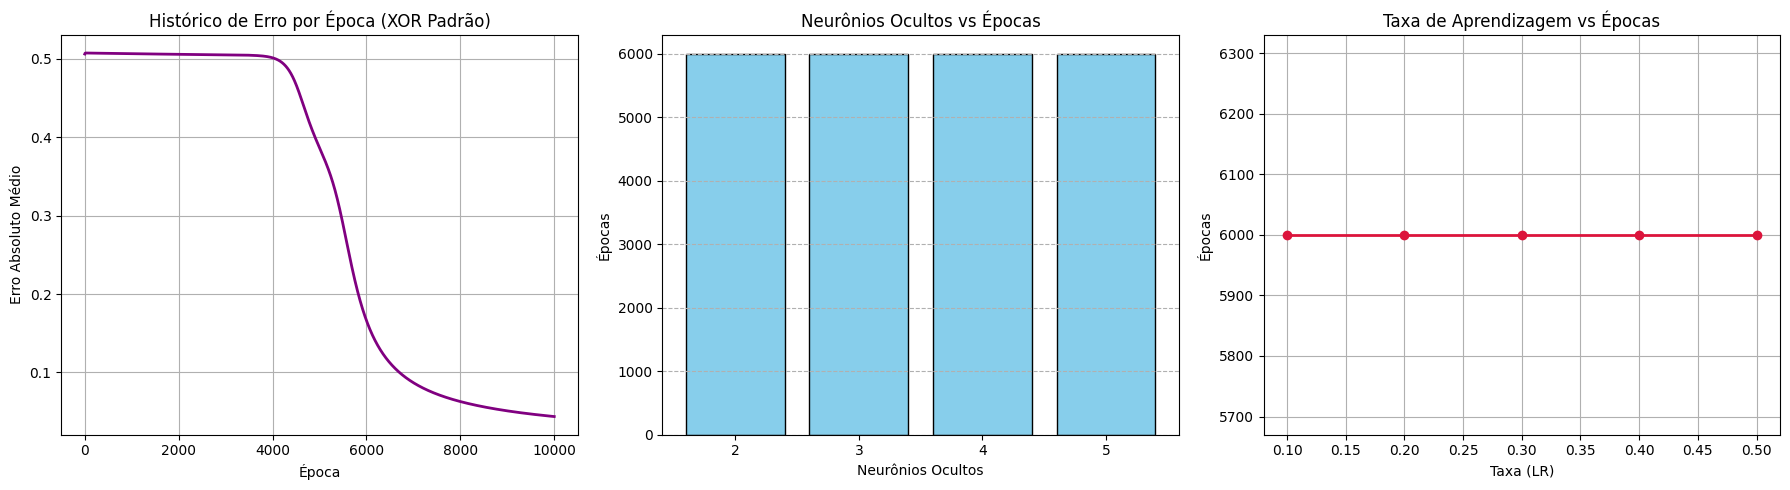

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# 1. Gráfico Erro x Época (Pedido explicitamente na Parte 6)
axs[0].plot(historico_erros, color='purple', linewidth=2)
axs[0].set_title("Histórico de Erro por Época (XOR Padrão)")
axs[0].set_xlabel("Época")
axs[0].set_ylabel("Erro Absoluto Médio")
axs[0].grid(True)

# 2. Gráfico do Experimento A
axs[1].bar(df_A["Neurônios Ocultos"].astype(str), df_A["Número de Épocas (Média)"], color='skyblue', edgecolor='black')
axs[1].set_title("Neurônios Ocultos vs Épocas")
axs[1].set_xlabel("Neurônios Ocultos")
axs[1].set_ylabel("Épocas")
axs[1].grid(axis='y', linestyle='--')

# 3. Gráfico do Experimento B
axs[2].plot(df_B["Taxa de Aprendizagem"], df_B["Épocas até Convergência"], marker='o', color='crimson', linewidth=2)
axs[2].set_title("Taxa de Aprendizagem vs Épocas")
axs[2].set_xlabel("Taxa (LR)")
axs[2].set_ylabel("Épocas")
axs[2].grid(True)

plt.tight_layout()
print("\nExibindo Gráficos Estatísticos do Treinamento...")
plt.show()